In [ ]:
import clip
import torch
from PIL import Image
import numpy as np
import gym
from stable_baselines3 import DQN, SAC
from stable_baselines3.common.vec_env import DummyVecEnv
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

c:\Users\Asus\anaconda3\envs\rl\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: [WinError 127] The specified procedure could not be found
  warn(f"Failed to load image Python extension: {e}")


In [ ]:

def load_clip_model(device='cpu'):
   
    clip_model, preprocess = clip.load("ViT-B/16", device=device)
    return clip_model, preprocess

def compute_embeddings(clip_model, preprocess, inputs, device='cpu'):
    
    with torch.no_grad():
        if isinstance(inputs, list):  # Text inputs
            embeddings = clip_model.encode_text(clip.tokenize(inputs).to(device))
        else:  # Image input
            img = preprocess(inputs).unsqueeze(0).to(device)
            embeddings = clip_model.encode_image(img)
    return embeddings


In [ ]:
def compute_cosine_reward(state, task_description, clip_model, preprocess, device='cpu'):
    img = Image.fromarray((state * 255).astype(np.uint8))  # Convert state to image
    image_features = compute_embeddings(clip_model, preprocess, img, device=device)
    text_features = compute_embeddings(clip_model, preprocess, [task_description], device=device)
    reward = torch.cosine_similarity(image_features, text_features).item()
    return reward

def compute_regularized_clip_reward(state, task_description, clip_model, preprocess, baseline_embedding, alpha=1.0, device='cpu'):
    img = Image.fromarray((state * 255).astype(np.uint8))  # Convert state to image
    state_embedding = compute_embeddings(clip_model, preprocess, img, device=device)
    task_embedding = compute_embeddings(clip_model, preprocess, [task_description], device=device)
    
    projection_vector = task_embedding - baseline_embedding
    projection = (torch.dot(state_embedding.squeeze(), projection_vector.squeeze()) /
                  torch.dot(projection_vector.squeeze(), projection_vector.squeeze())) * projection_vector
    regularized_embedding = alpha * projection + (1 - alpha) * state_embedding
    reward = 1 - 0.5 * torch.norm(regularized_embedding - task_embedding).item() ** 2
    return reward


In [ ]:
class ClipRewardEnv(gym.Env):
    def __init__(self, env, task_description, clip_model, preprocess, reward_type='cosine', baseline_embedding=None, alpha=1.0, device='cpu'):
        super(ClipRewardEnv, self).__init__()
        self.env = env
        self.task_description = task_description
        self.clip_model = clip_model
        self.preprocess = preprocess
        self.reward_type = reward_type
        self.baseline_embedding = baseline_embedding
        self.alpha = alpha
        self.device = device

        self.observation_space = self.env.observation_space
        self.action_space = self.env.action_space

    def reset(self):
        state, _ = self.env.reset()
        return np.array(state, dtype=np.float32)

    def step(self, action):
        state, _, terminated, truncated, info = self.env.step(action)
        if self.reward_type == 'cosine':
            reward = compute_cosine_reward(state, self.task_description, self.clip_model, self.preprocess, device=self.device)
        else:
            reward = compute_regularized_clip_reward(state, self.task_description, self.clip_model, self.preprocess, self.baseline_embedding, alpha=self.alpha, device=self.device)
        done = terminated or truncated
        return np.array(state, dtype=np.float32), reward, done, info


In [ ]:
def train_agent(env, algo='DQN', total_timesteps=10000):
    if algo == 'DQN':
        model = DQN("MlpPolicy", env, verbose=1)
    elif algo == 'SAC':
        model = SAC("MlpPolicy", env, verbose=1)
    model.learn(total_timesteps=total_timesteps)
    return model

def test_agent(model, env, episodes=10):
    for ep in range(episodes):
        obs = env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs)
            obs, reward, done, info = env.step(action)


In [ ]:

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, preprocess = load_clip_model(device)

task_description = "a car at the peak of the mountain, next to the yellow flag "
baseline_description = " a car in the mountain "


baseline_embedding = compute_embeddings(clip_model, preprocess, [baseline_description], device=device)


env = gym.make("MountainCar-v0")
clip_reward_env = ClipRewardEnv(env, task_description, clip_model, preprocess, reward_type='regularized', baseline_embedding=baseline_embedding, alpha=0.95, device=device)
vec_env = DummyVecEnv([lambda: clip_reward_env])


c:\Users\Asus\anaconda3\envs\rl\lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [ ]:
model = DQN(
    "MlpPolicy",
    vec_env,                        
    buffer_size=100000,            
    batch_size=64,                 
    learning_rate=lambda progress: 2.3e-3 * (1 - progress),  
    train_freq=(200, "step"),    
    gradient_steps=300,            
    gamma=0.99,                    
    exploration_fraction=0.95,      
    exploration_final_eps=0.01,    
    target_update_interval=1000,   
    verbose=1,                     
    policy_kwargs={"net_arch": [256, 256]}  
)


Using cpu device


In [8]:
model.learn(total_timesteps=100000)

c:\Users\Asus\anaconda3\envs\rl\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


----------------------------------
| rollout/            |          |
|    exploration_rate | 0.992    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 3        |
|    time_elapsed     | 218      |
|    total_timesteps  | 800      |
| train/              |          |
|    learning_rate    | 1.38e-05 |
|    loss             | 30.4     |
|    n_updates        | 900      |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.983    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 3        |
|    time_elapsed     | 430      |
|    total_timesteps  | 1600     |
| train/              |          |
|    learning_rate    | 3.22e-05 |
|    loss             | 15.9     |
|    n_updates        | 2100     |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rat

In [ ]:
positions = []
velocities = []
rewards = []

obs = vec_env.reset()  
for _ in range(5000): 

    action, _ = model.predict(obs)

  
    obs, reward, done, info = vec_env.step(action)

  
    position = float(obs[0][0])  
    velocity = float(obs[0][1])  
    positions.append(position)
    velocities.append(velocity)

    
    rewards.append(float(reward[0]))  

    if done[0]:  
        obs = vec_env.reset()


positions = np.array(positions)
velocities = np.array(velocities)
rewards = np.array(rewards)


normalized_rewards = (rewards - rewards.min()) / (rewards.max() - rewards.min())


In [11]:
type(positions)

numpy.ndarray

In [ ]:
print(f"Min Pole Angle: {normalized_rewards.min()}, Max Pole Angle: {normalized_rewards.max()}")


Min Pole Angle: 0.0, Max Pole Angle: 1.0


In [ ]:
print(f"Min Pole Angle: {positions.min()}, Max Pole Angle: {positions.max()}")


Min Pole Angle: -0.6439257860183716, Max Pole Angle: -0.4016587436199188


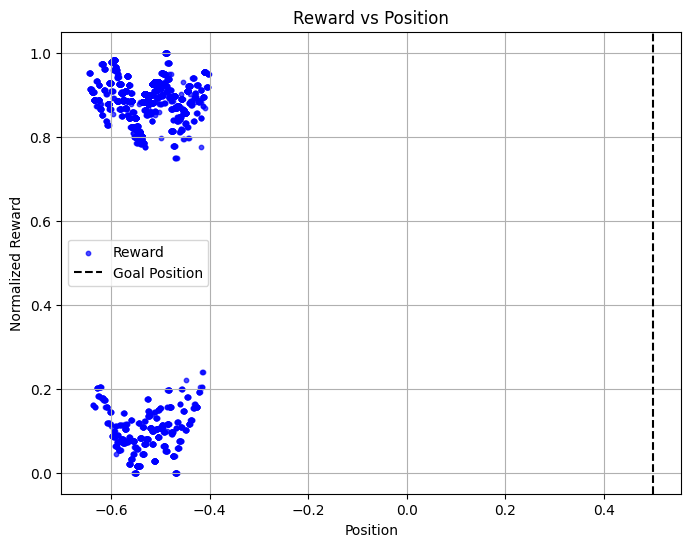

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(positions, normalized_rewards, s=10, alpha=0.7, color='blue', label='Reward')
plt.axvline(x=0.5, color='black', linestyle='--', label='Goal Position')
plt.xlabel("Position")
plt.ylabel("Normalized Reward")
plt.title("Reward vs Position")
plt.legend()
plt.grid()
plt.show()


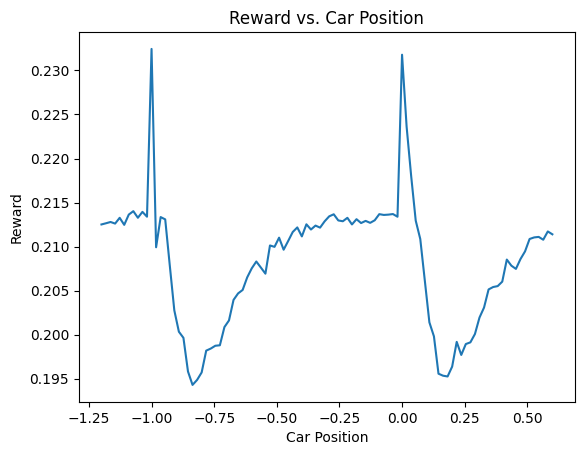

In [ ]:
positions = np.linspace(-1.2, 0.6, num=100)  
velocities = [0.0] 

rewards = []


for position in positions:
    
    synthetic_state = np.array([position, velocities[0]])  

    
    reward = compute_cosine_reward(
        synthetic_state, 
        task_description="a car at the peak of the mountain, next to the yellow flag", 
        clip_model=clip_model, 
        preprocess=preprocess, 
        device=device
    )
    rewards.append(reward)


plt.plot(positions, rewards)
plt.xlabel("Car Position")
plt.ylabel("Reward")
plt.title("Reward vs. Car Position")
plt.show()
